# Contagion Simulations — Dataset 2

Same workflow as notebook 02 applied to Dataset 2 (1 444 European banks).

In [14]:
import sys
from pathlib import Path
import os

%matplotlib inline

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / 'src').exists() and (path / 'requirements.txt').exists():
            return path
    raise FileNotFoundError('Project root not found.')


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.models.contagion import run_default_contagion_analysis

## Config

In [15]:
MECHANISM = 'Exposure'
ALPHA = 1.0
TRACK_ROUNDS = True

PROJECT_ROOT = find_project_root()
DATASET2_PATH = PROJECT_ROOT / 'src' / 'datasets' / 'dataset_2'
TARGET_DIR    = DATASET2_PATH / 'targets'

TABLE_DIRS = {
    'runs':          DATASET2_PATH / 'sim_runs',
    'bank_state':    DATASET2_PATH / 'sim_bank_state',
    'round_summary': DATASET2_PATH / 'sim_round_summary',
    'importance':    DATASET2_PATH / 'systemic_importance',
}

for path in list(TABLE_DIRS.values()) + [TARGET_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print('Output directories:')
for name, path in TABLE_DIRS.items():
    print(f'  {name:13s} -> {path}')
print(f'  {"target":13s} -> {TARGET_DIR}')

Output directories:
  runs          -> /Users/rubenmarques/Documents/Repositórios/Thesis/src/datasets/dataset_2/sim_runs
  bank_state    -> /Users/rubenmarques/Documents/Repositórios/Thesis/src/datasets/dataset_2/sim_bank_state
  round_summary -> /Users/rubenmarques/Documents/Repositórios/Thesis/src/datasets/dataset_2/sim_round_summary
  importance    -> /Users/rubenmarques/Documents/Repositórios/Thesis/src/datasets/dataset_2/systemic_importance
  target        -> /Users/rubenmarques/Documents/Repositórios/Thesis/src/datasets/dataset_2/targets


## Load Dataset 2

In [16]:
def load_dataset2_nodes(dataset_path):
    """
    Load nodes.csv and add the columns required by the contagion model.
    'index'  — 0-based integer preserving CSV row order.
    'Equity' — buffer (Total Capital = TIER1+TIER2, the solvency buffer).
    'Assets' — assets (Net Loans to Banks, interbank assets).
    """
    nodes = pd.read_csv(dataset_path / 'nodes.csv')
    nodes = nodes.reset_index(drop=True)
    nodes['index']  = nodes.index
    nodes['Equity'] = nodes['buffer']
    nodes['Assets'] = nodes['assets']
    return nodes


def load_dataset2_edges(dataset_path, bank_to_idx):
    """
    Load network.xlsx (adjacency matrix) and convert to edge-list format
    [Sourceid, Targetid, Weights].
    Row = lender (Sourceid), column = borrower (Targetid). Zero entries are dropped.
    """
    matrix = pd.read_excel(dataset_path / 'network.xlsx', index_col=0)
    edges_long = matrix.stack().reset_index()
    edges_long.columns = ['source_bank', 'target_bank', 'Weights']
    edges_long = edges_long[edges_long['Weights'] != 0].copy()
    edges_long['Sourceid'] = edges_long['source_bank'].map(bank_to_idx)
    edges_long['Targetid'] = edges_long['target_bank'].map(bank_to_idx)
    edges_long = edges_long.dropna(subset=['Sourceid', 'Targetid'])
    edges_long['Sourceid'] = edges_long['Sourceid'].astype(int)
    edges_long['Targetid'] = edges_long['Targetid'].astype(int)
    return edges_long[['Sourceid', 'Targetid', 'Weights']].reset_index(drop=True)


def save_outputs_dataset2(outputs, table_dirs, target_dir):
    """Save simulation outputs to the dataset_2 directories."""
    file_map = {
        'runs':          table_dirs['runs']          / 'sim_runs.parquet',
        'bank_state':    table_dirs['bank_state']    / 'sim_bank_state.parquet',
        'round_summary': table_dirs['round_summary'] / 'sim_round_summary.parquet',
        'importance':    table_dirs['importance']    / 'systemic_importance.parquet',
        'target':        target_dir                  / 'target.csv',
    }
    for key, path in file_map.items():
        df = outputs[key]
        if key == 'target':
            df.to_csv(path, index=False)
        else:
            df.to_parquet(path, index=False)
    return {k: str(v) for k, v in file_map.items()}

In [17]:
nodes = load_dataset2_nodes(DATASET2_PATH)
bank_to_idx = dict(zip(nodes['bank'], nodes['index']))
edges = load_dataset2_edges(DATASET2_PATH, bank_to_idx)

print(f'Banks:   {len(nodes):,}')
print(f'Edges:   {len(edges):,}')
print()
display(nodes[['index', 'bank', 'assets', 'liabilities', 'Equity', 'Assets']].head())
display(edges.head())

Banks:   1,444
Edges:   2,893



,index,bank,assets,liabilities,Equity,Assets
0,0,b1,266508.633115,21467.258984,1.767190e+05,266508.633115
1,1,b10,3593.873481,31049.212324,6.966636e+04,3593.873481
2,2,b100,12766.073055,15804.110997,2.535776e+04,12766.073055
3,3,b1000,511397.892389,466472.406209,4.753911e+06,511397.892389
4,4,b1001,534861.922281,688709.290061,2.611763e+06,534861.922281


,Sourceid,Targetid,Weights
0,0,400,266508.633115
1,556,224,163908.561614
2,667,717,28435.707370
3,778,635,879.151286
4,889,237,29568.812630


## Run Simulation

In [18]:
# output_dir=None — we save manually below to keep everything inside dataset_2/.
outputs = run_default_contagion_analysis(
    edges=edges,
    nodes=nodes,
    year=1,
    quarter=1,
    mechanism=MECHANISM,
    alpha=ALPHA,
    track_rounds=TRACK_ROUNDS,
    output_dir=None,
)

runs_df           = outputs['runs']
bank_state_df     = outputs['bank_state']
round_summary_df  = outputs['round_summary']
importance_df     = outputs['importance']

print('Generated tables:')
print(f'  runs          : {runs_df.shape}')
print(f'  bank_state    : {bank_state_df.shape}')
print(f'  round_summary : {round_summary_df.shape}')
print(f'  importance    : {importance_df.shape}')

saved_files = save_outputs_dataset2(outputs, TABLE_DIRS, TARGET_DIR)
print('\nWritten files:')
for key, path in saved_files.items():
    print(f'  {key:13s} -> {path}')

Generated tables:
  runs          : (1444, 27)
  bank_state    : (5622, 14)
  round_summary : (1619, 7)
  importance    : (1444, 26)

Written files:
  runs          -> /Users/rubenmarques/Documents/Repositórios/Thesis/src/datasets/dataset_2/sim_runs/sim_runs.parquet
  bank_state    -> /Users/rubenmarques/Documents/Repositórios/Thesis/src/datasets/dataset_2/sim_bank_state/sim_bank_state.parquet
  round_summary -> /Users/rubenmarques/Documents/Repositórios/Thesis/src/datasets/dataset_2/sim_round_summary/sim_round_summary.parquet
  importance    -> /Users/rubenmarques/Documents/Repositórios/Thesis/src/datasets/dataset_2/systemic_importance/systemic_importance.parquet
  target        -> /Users/rubenmarques/Documents/Repositórios/Thesis/src/datasets/dataset_2/targets/target.csv


## Systemic Importance Ranking

In [19]:
ranking_cols = [
    'bank_id',
    'systemic_risk_label',
    'num_impacted',
    'secondary_defaults',
    'failed_equity_loss',
    'system_equity_depletion',
    'affected_assets',
    'affected_assets_share',
    'cascade_rank',
    'impact_rank',
    'loss_rank',
]

display(importance_df[ranking_cols].head(20))

,bank_id,systemic_risk_label,num_impacted,secondary_defaults,failed_equity_loss,system_equity_depletion,affected_assets,affected_assets_share,cascade_rank,impact_rank,loss_rank
0,207,60,207,59,2.265196e+08,4.940797e+08,4.842243e+08,0.143352,1,1,1
1,635,36,123,35,8.848995e+07,2.691603e+08,2.877275e+08,0.085180,2,3,4
2,628,33,126,32,1.216868e+08,2.889050e+08,2.947452e+08,0.087258,3,2,3
3,714,32,111,31,6.387229e+07,2.348889e+08,2.596565e+08,0.076870,4,5,6
4,394,27,117,26,2.271709e+08,3.613309e+08,2.736920e+08,0.081025,5,4,2
5,398,26,94,25,8.231879e+07,1.978354e+08,2.198893e+08,0.065097,6,7,7
6,713,24,80,23,1.344787e+08,2.626842e+08,1.871398e+08,0.055402,7,9,5
7,211,21,96,20,4.807853e+07,1.718752e+08,2.245678e+08,0.066482,8,6,8
8,208,19,66,18,6.974341e+07,1.523528e+08,1.543903e+08,0.045706,9,10,13
9,403,17,84,16,3.327581e+07,1.468363e+08,1.964968e+08,0.058172,10,8,15


In [20]:
summary_stats = importance_df[
    [
        'systemic_risk_label',
        'secondary_defaults',
        'num_impacted',
        'failed_equity_loss',
        'system_equity_depletion',
        'affected_assets_share',
    ]
].describe()

display(summary_stats)

,systemic_risk_label,secondary_defaults,num_impacted,failed_equity_loss,system_equity_depletion,affected_assets_share
count,1444.000000,1444.000000,1444.000000,1.444000e+03,1.444000e+03,1444.000000
mean,1.443213,0.443213,3.893352,2.780519e+06,5.840010e+06,0.002696
std,2.811513,2.811513,10.798333,1.319472e+07,2.750114e+07,0.007478
min,1.000000,0.000000,2.000000,1.499919e+03,2.944825e+03,0.001385
25%,1.000000,0.000000,2.000000,5.794700e+04,8.868435e+04,0.001385
50%,1.000000,0.000000,2.000000,1.824140e+05,3.156527e+05,0.001385
75%,1.000000,0.000000,2.000000,7.581030e+05,1.380648e+06,0.001385
max,60.000000,59.000000,207.000000,2.271709e+08,4.940797e+08,0.143352


## Distribution

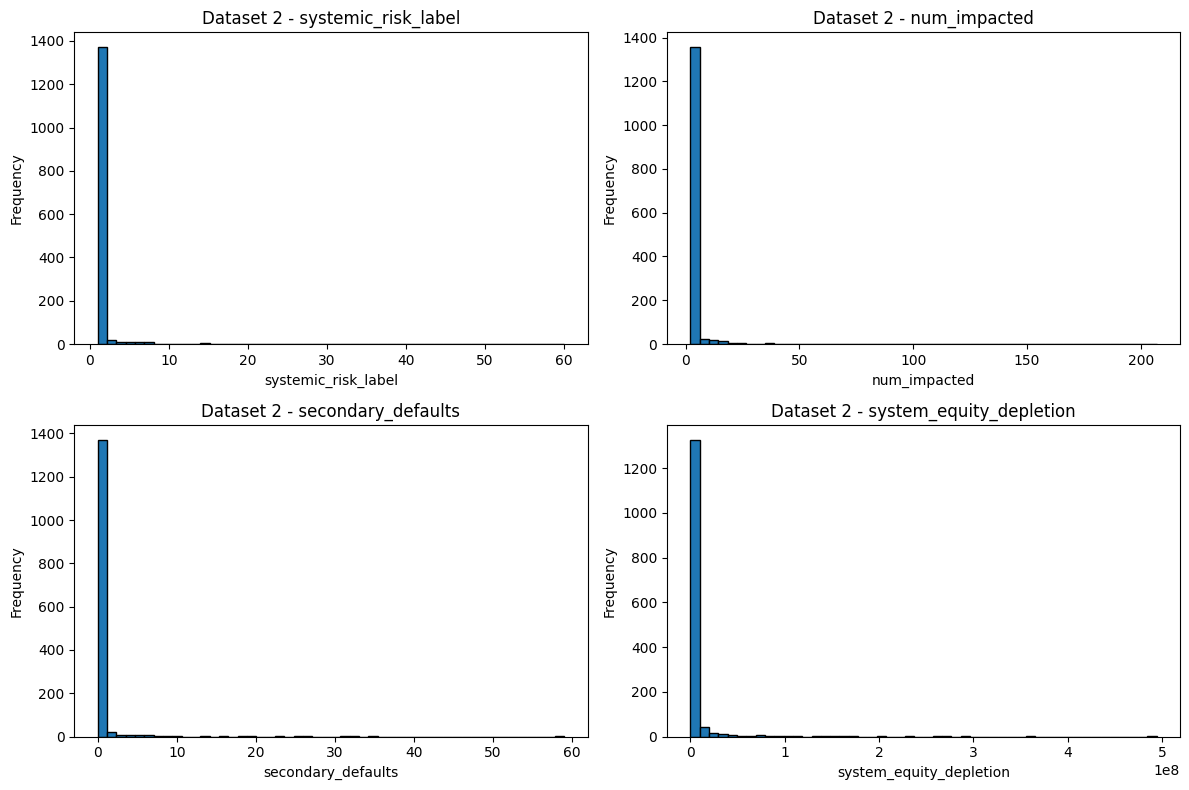

In [21]:
dist_cols = [
    'systemic_risk_label',
    'num_impacted',
    'secondary_defaults',
    'system_equity_depletion',
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, col in zip(axes, dist_cols):
    importance_df[col].plot(kind='hist', bins=50, ax=ax, edgecolor='black')
    ax.set_title(f'Dataset 2 - {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [22]:
quantiles = importance_df[
    ['systemic_risk_label', 'num_impacted', 'secondary_defaults',
     'system_equity_depletion', 'failed_equity_loss']
].quantile([0.50, 0.75, 0.90, 0.95, 0.99])

display(quantiles)

,systemic_risk_label,num_impacted,secondary_defaults,system_equity_depletion,failed_equity_loss
0.50,1.00,2.00,0.00,3.156527e+05,1.824140e+05
0.75,1.00,2.00,0.00,1.380648e+06,7.581030e+05
0.90,1.00,4.00,0.00,6.975361e+06,3.177505e+06
0.95,2.85,9.85,1.85,2.120235e+07,9.811861e+06
0.99,12.71,53.71,11.71,1.444571e+08,6.135332e+07


## Table Validation

In [23]:
runs_check          = pd.read_parquet(TABLE_DIRS['runs']          / 'sim_runs.parquet')
bank_state_check    = pd.read_parquet(TABLE_DIRS['bank_state']    / 'sim_bank_state.parquet')
round_summary_check = pd.read_parquet(TABLE_DIRS['round_summary'] / 'sim_round_summary.parquet')
importance_check    = pd.read_parquet(TABLE_DIRS['importance']    / 'systemic_importance.parquet')

print(runs_check.shape)
print(bank_state_check.shape)
print(round_summary_check.shape)
print(importance_check.shape)

(1444, 27)
(5622, 14)
(1619, 7)
(1444, 26)


In [24]:
# Check 1: one run per initial bank
assert len(runs_check) == len(nodes), 'Expected one simulation run per bank.'

# Check 2: num_failed must match failed-bank count in bank_state
failed_counts = (
    bank_state_check[bank_state_check['failed']]
    .groupby('run_id')
    .size()
    .rename('failed_in_bank_state')
    .reset_index()
)

cross_check = runs_check[['run_id', 'num_failed']].merge(
    failed_counts, on='run_id', how='left'
)
cross_check['failed_in_bank_state'] = cross_check['failed_in_bank_state'].fillna(0).astype(int)

mismatches = cross_check[cross_check['num_failed'] != cross_check['failed_in_bank_state']]
print('Cross-table mismatches:', len(mismatches))
assert mismatches.empty, 'Tables are inconsistent.'

# Check 3: one ranking row per bank
assert len(importance_check) == len(nodes), 'Expected one ranking row per bank.'
assert importance_check['bank_id'].is_unique, 'Each bank should appear once in the ranking table.'

print('All validation checks passed.')

Cross-table mismatches: 0
All validation checks passed.


## Log Transformation of Targets

In [25]:
target_path = TARGET_DIR / 'target.csv'
target_df = pd.read_csv(target_path)
target_df['log_systemic_risk_label'] = np.log1p(target_df['systemic_risk_label'])
target_df.to_csv(target_path, index=False)

print(f'Target rows: {len(target_df):,}')
display(target_df[['systemic_risk_label', 'log_systemic_risk_label']].describe())

Target rows: 1,444


,systemic_risk_label,log_systemic_risk_label
count,1444.000000,1444.000000
mean,1.443213,0.775592
std,2.811513,0.335310
min,1.000000,0.693147
25%,1.000000,0.693147
50%,1.000000,0.693147
75%,1.000000,0.693147
max,60.000000,4.110874


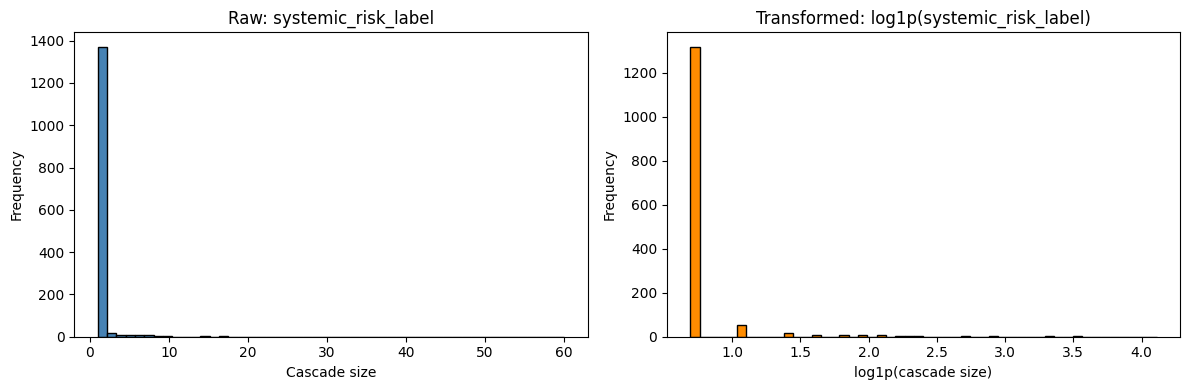

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_df['systemic_risk_label'].plot(
    kind='hist', bins=50, ax=axes[0], edgecolor='black', color='steelblue'
)
axes[0].set_title('Raw: systemic_risk_label')
axes[0].set_xlabel('Cascade size')
axes[0].set_ylabel('Frequency')

target_df['log_systemic_risk_label'].plot(
    kind='hist', bins=50, ax=axes[1], edgecolor='black', color='darkorange'
)
axes[1].set_title('Transformed: log1p(systemic_risk_label)')
axes[1].set_xlabel('log1p(cascade size)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Partial Loss Simulations (p = 10 % – 40 %)

In [27]:
def run_contagion_for_p(edges, nodes, p):
    """
    Run the contagion simulation with default threshold = p% equity loss.
    Implemented by setting Equity = (1 - p) * buffer so the model's
    'remaining_equity <= 0' condition fires when the bank has lost p% of
    its actual equity buffer.
    """
    nodes_p = nodes.copy()
    nodes_p['Equity'] = (1 - p) * nodes_p['buffer']
    return run_default_contagion_analysis(
        edges=edges,
        nodes=nodes_p,
        year=1,
        quarter=1,
        mechanism=MECHANISM,
        alpha=ALPHA,
        track_rounds=TRACK_ROUNDS,
        output_dir=None,
    )

In [28]:
P_THRESHOLDS = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]

for p in P_THRESHOLDS:
    label = f'p{int(p * 100)}'
    print(f'Running p={int(p*100)}%...', end=' ')

    out = run_contagion_for_p(edges, nodes, p)

    # Save to dataset_2 dirs with p label in filename
    for key, subdir in TABLE_DIRS.items():
        fname = subdir / f'sim_{key}_{label}.parquet' if key != 'importance' else subdir / f'systemic_importance_{label}.parquet'
        out[key].to_parquet(fname, index=False)
    target_path = TARGET_DIR / f'target_{label}.csv'
    out['target']['log_systemic_risk_label'] = np.log1p(out['target']['systemic_risk_label'])
    out['target'].to_csv(target_path, index=False)

    imp = out['importance']
    print(f"banks={len(imp)}, max_cascade={int(imp['systemic_risk_label'].max())}")

print('Done.')

Running p=5%... banks=1444, max_cascade=60
Running p=10%... banks=1444, max_cascade=60
Running p=15%... banks=1444, max_cascade=62
Running p=20%... banks=1444, max_cascade=65
Running p=25%... banks=1444, max_cascade=67
Running p=30%... banks=1444, max_cascade=75
Running p=35%... banks=1444, max_cascade=77
Running p=40%... banks=1444, max_cascade=102
Done.
